In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("C:/Users/sahus/Downloads/smart_atm_cash_refill_dataset.csv")

In [3]:
df.head()

,ATM_ID,Date,Day_of_Week,Month,Location_Type,ATM_Type,Nearby_Market,Festival_Season,Salary_Week,Holiday,...,Current_Cash_Balance,Transactions_Today,Working_Hours,ATM_Age_Years,Maintenance_Due,Nearest_Bank_Distance_km,Population_Density,Nearby_Businesses,Weekend,Needs_Refill
0,ATM1327,2023-04-25,Tuesday,April,Urban,Offsite,No,No,No,No,...,10000,561,16,9,No,13.21,High,88,No,Yes
1,ATM1125,2023-08-17,Thursday,August,Urban,Onsite,No,Yes,No,No,...,738699,426,16,4,Yes,23.73,High,66,No,Yes
2,ATM1346,2024-07-12,Friday,July,Rural,Offsite,Yes,Yes,No,No,...,1813354,142,16,19,No,19.42,Low,24,No,No
3,ATM1216,2023-02-02,Thursday,February,Rural,Offsite,No,No,Yes,Yes,...,448529,122,16,3,No,20.09,Low,0,No,No
4,ATM1111,2023-08-27,Sunday,August,Urban,Offsite,No,No,No,Yes,...,10000,445,24,20,No,8.26,High,52,Yes,No


In [4]:
df.shape

(10000, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ATM_ID                     10000 non-null  object 
 1   Date                       10000 non-null  object 
 2   Day_of_Week                10000 non-null  object 
 3   Month                      10000 non-null  object 
 4   Location_Type              10000 non-null  object 
 5   ATM_Type                   10000 non-null  object 
 6   Nearby_Market              10000 non-null  object 
 7   Festival_Season            10000 non-null  object 
 8   Salary_Week                10000 non-null  object 
 9   Holiday                    10000 non-null  object 
 10  Weather                    10000 non-null  object 
 11  Temperature_C              10000 non-null  float64
 12  Previous_Day_Withdrawals   10000 non-null  int64  
 13  Average_Withdrawal_Amount  10000 non-null  floa

In [6]:
df.describe()

,Temperature_C,Previous_Day_Withdrawals,Average_Withdrawal_Amount,Cash_Loaded,Current_Cash_Balance,Transactions_Today,Working_Hours,ATM_Age_Years,Nearest_Bank_Distance_km,Nearby_Businesses
count,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,31.396010,405.838100,4530.521600,1.744650e+06,5.851436e+05,406.389500,19.346400,10.533600,12.654676,44.094100
std,7.745268,174.778797,1934.263443,7.195728e+05,7.162498e+05,164.582874,3.406518,5.807172,7.212740,24.822765
min,18.000000,20.000000,500.000000,5.013970e+05,1.000000e+04,20.000000,16.000000,1.000000,0.200000,0.000000
25%,24.800000,274.000000,3183.032500,1.119358e+06,1.000000e+04,282.000000,16.000000,5.000000,6.300000,24.000000
50%,31.200000,409.000000,4527.145000,1.739031e+06,2.146080e+05,413.000000,18.000000,11.000000,12.870000,44.500000
75%,38.000000,540.000000,5859.035000,2.373264e+06,1.046187e+06,540.000000,24.000000,16.000000,18.970000,64.000000
max,45.000000,900.000000,10000.000000,2.999930e+06,2.945306e+06,869.000000,24.000000,20.000000,25.000000,100.000000


In [7]:
df.describe(include="object")

,ATM_ID,Date,Day_of_Week,Month,Location_Type,ATM_Type,Nearby_Market,Festival_Season,Salary_Week,Holiday,Weather,Maintenance_Due,Population_Density,Weekend,Needs_Refill
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,500,731,7,12,3,2,2,2,2,2,3,2,3,2,2
top,ATM1309,2024-10-08,Thursday,August,Urban,Onsite,Yes,No,No,No,Sunny,No,High,No,Yes
freq,33,25,1456,874,4502,6020,5033,8500,7264,9029,5503,8801,4095,7202,5000


In [8]:
df.isnull().sum()

ATM_ID                       0
Date                         0
Day_of_Week                  0
Month                        0
Location_Type                0
ATM_Type                     0
Nearby_Market                0
Festival_Season              0
Salary_Week                  0
Holiday                      0
Weather                      0
Temperature_C                0
Previous_Day_Withdrawals     0
Average_Withdrawal_Amount    0
Cash_Loaded                  0
Current_Cash_Balance         0
Transactions_Today           0
Working_Hours                0
ATM_Age_Years                0
Maintenance_Due              0
Nearest_Bank_Distance_km     0
Population_Density           0
Nearby_Businesses            0
Weekend                      0
Needs_Refill                 0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

ATM_ID                        object
Date                          object
Day_of_Week                   object
Month                         object
Location_Type                 object
ATM_Type                      object
Nearby_Market                 object
Festival_Season               object
Salary_Week                   object
Holiday                       object
Weather                       object
Temperature_C                float64
Previous_Day_Withdrawals       int64
Average_Withdrawal_Amount    float64
Cash_Loaded                    int64
Current_Cash_Balance           int64
Transactions_Today             int64
Working_Hours                  int64
ATM_Age_Years                  int64
Maintenance_Due               object
Nearest_Bank_Distance_km     float64
Population_Density            object
Nearby_Businesses              int64
Weekend                       object
Needs_Refill                  object
dtype: object

In [11]:
df.columns

Index(['ATM_ID', 'Date', 'Day_of_Week', 'Month', 'Location_Type', 'ATM_Type',
       'Nearby_Market', 'Festival_Season', 'Salary_Week', 'Holiday', 'Weather',
       'Temperature_C', 'Previous_Day_Withdrawals',
       'Average_Withdrawal_Amount', 'Cash_Loaded', 'Current_Cash_Balance',
       'Transactions_Today', 'Working_Hours', 'ATM_Age_Years',
       'Maintenance_Due', 'Nearest_Bank_Distance_km', 'Population_Density',
       'Nearby_Businesses', 'Weekend', 'Needs_Refill'],
      dtype='object')

<Axes: xlabel='Needs_Refill', ylabel='count'>

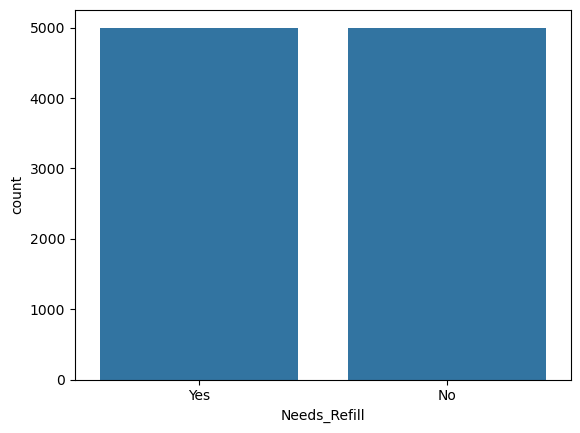

In [12]:
sns.countplot(data=df, x="Needs_Refill")

array([[<Axes: title={'center': 'Temperature_C'}>,
        <Axes: title={'center': 'Previous_Day_Withdrawals'}>,
        <Axes: title={'center': 'Average_Withdrawal_Amount'}>],
       [<Axes: title={'center': 'Cash_Loaded'}>,
        <Axes: title={'center': 'Current_Cash_Balance'}>,
        <Axes: title={'center': 'Transactions_Today'}>],
       [<Axes: title={'center': 'Working_Hours'}>,
        <Axes: title={'center': 'ATM_Age_Years'}>,
        <Axes: title={'center': 'Nearest_Bank_Distance_km'}>],
       [<Axes: title={'center': 'Nearby_Businesses'}>, <Axes: >,
        <Axes: >]], dtype=object)

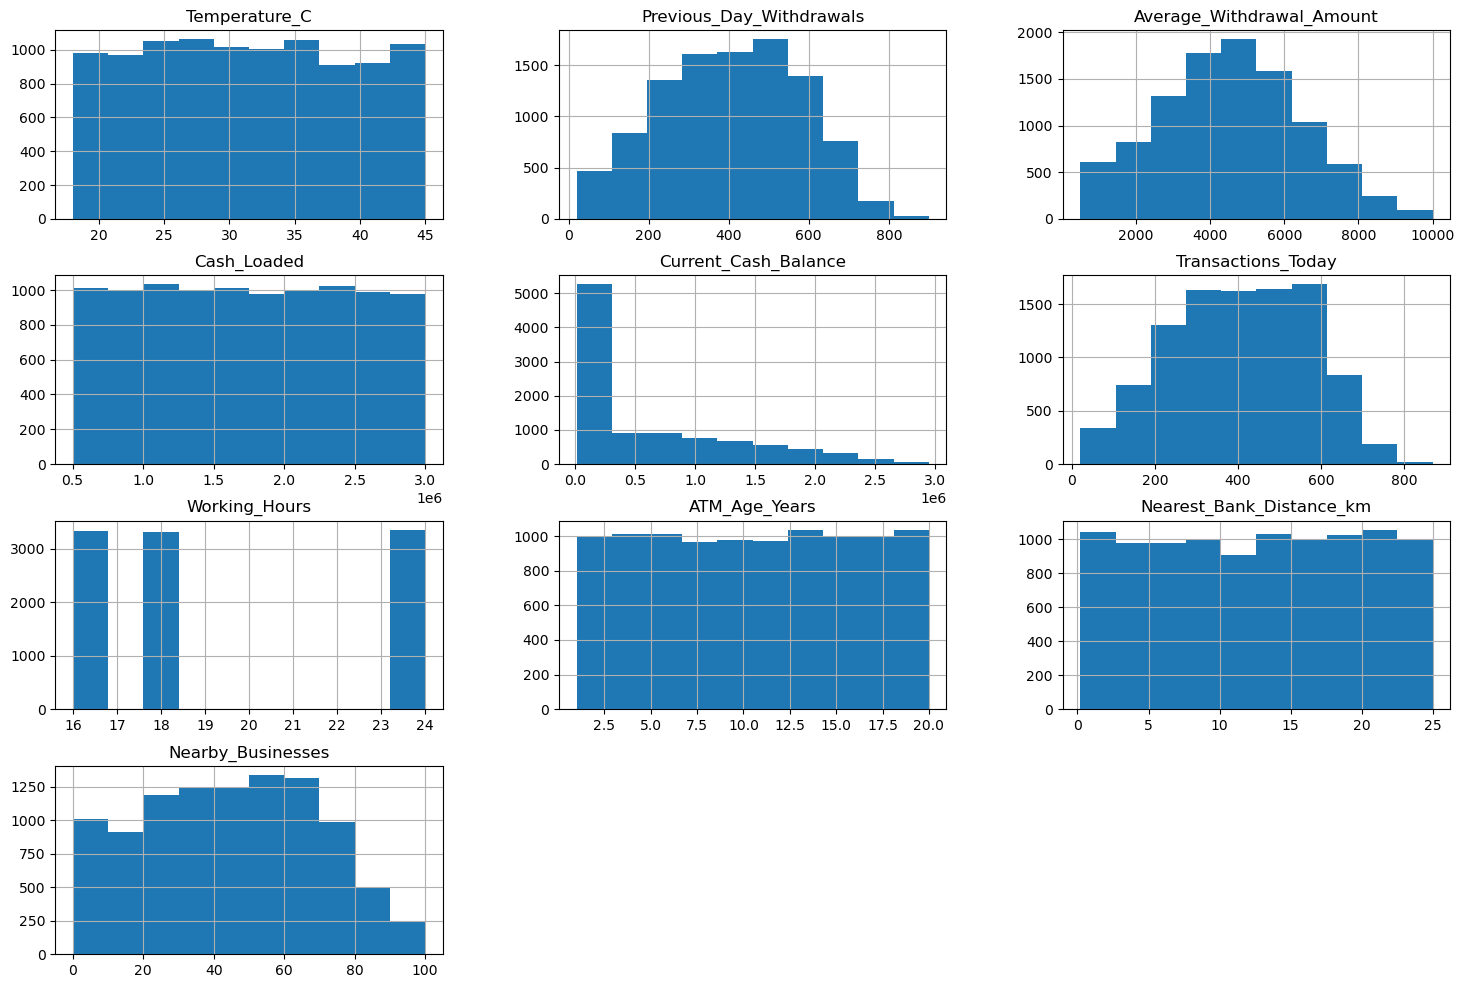

In [13]:
df.hist(figsize=(18,12))

<Axes: >

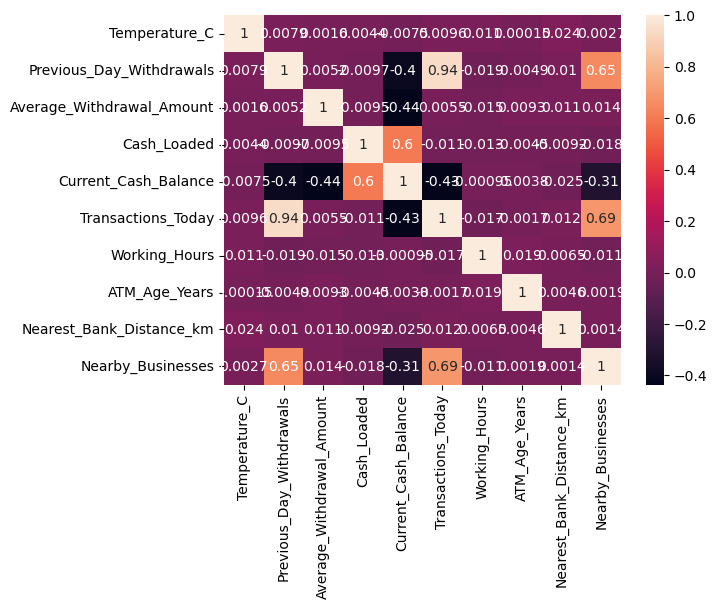

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='Needs_Refill', ylabel='Transactions_Today'>

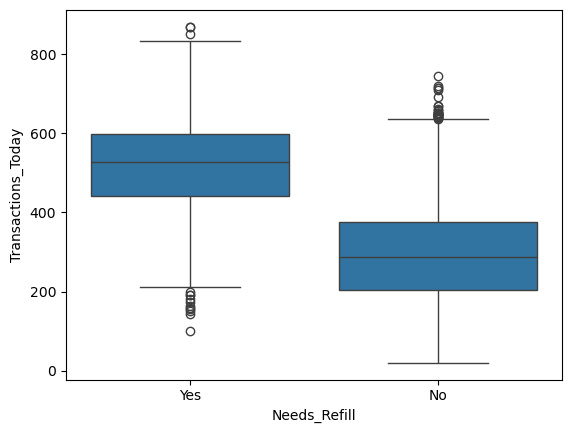

In [15]:
sns.boxplot(
    data=df,
    x="Needs_Refill",
    y="Transactions_Today"
)

<Axes: xlabel='Needs_Refill', ylabel='Current_Cash_Balance'>

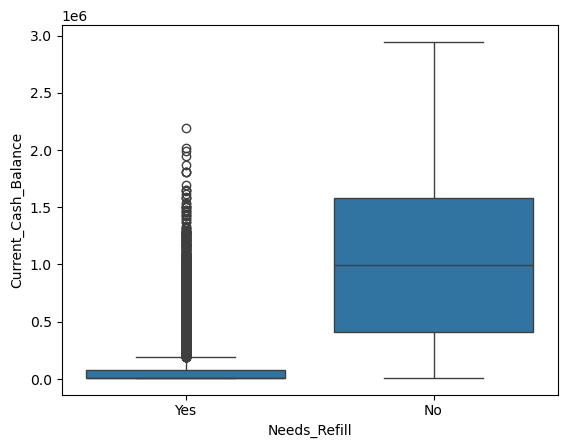

In [16]:
sns.boxplot(
    data=df,
    x="Needs_Refill",
    y="Current_Cash_Balance"
)

<Axes: xlabel='Needs_Refill', ylabel='Previous_Day_Withdrawals'>

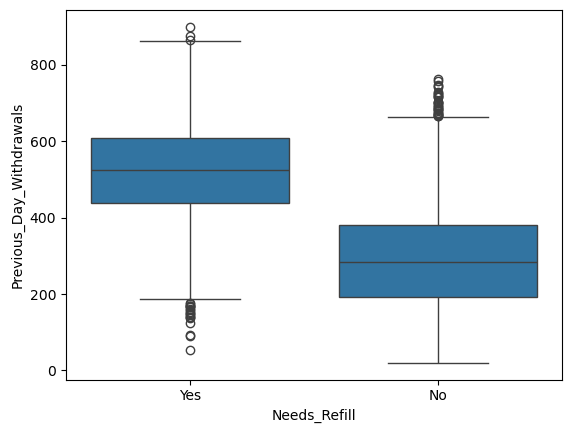

In [17]:
sns.boxplot(
    data=df,
    x="Needs_Refill",
    y="Previous_Day_Withdrawals"
)

<Axes: xlabel='Location_Type', ylabel='count'>

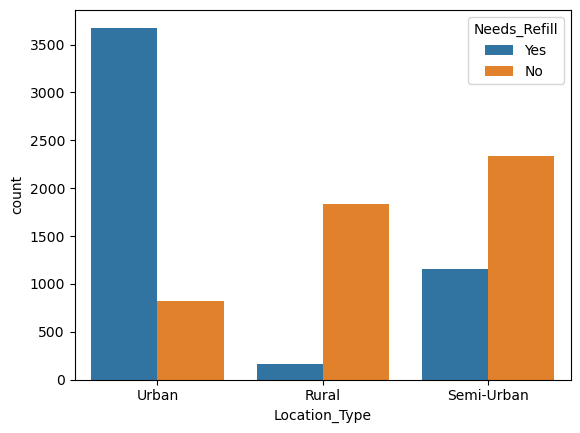

In [18]:
sns.countplot(
    data=df,
    x="Location_Type",
    hue="Needs_Refill"
)

<Axes: xlabel='Salary_Week', ylabel='count'>

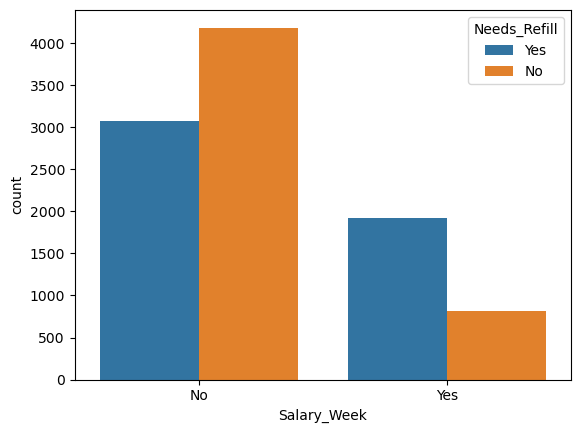

In [19]:
sns.countplot(
    data=df,
    x="Salary_Week",
    hue="Needs_Refill"
)

<Axes: xlabel='Festival_Season', ylabel='count'>

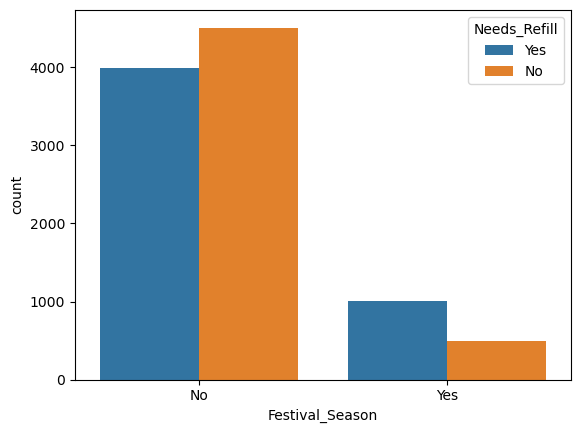

In [20]:
sns.countplot(
    data=df,
    x="Festival_Season",
    hue="Needs_Refill"
)

In [21]:
df.dtypes

ATM_ID                        object
Date                          object
Day_of_Week                   object
Month                         object
Location_Type                 object
ATM_Type                      object
Nearby_Market                 object
Festival_Season               object
Salary_Week                   object
Holiday                       object
Weather                       object
Temperature_C                float64
Previous_Day_Withdrawals       int64
Average_Withdrawal_Amount    float64
Cash_Loaded                    int64
Current_Cash_Balance           int64
Transactions_Today             int64
Working_Hours                  int64
ATM_Age_Years                  int64
Maintenance_Due               object
Nearest_Bank_Distance_km     float64
Population_Density            object
Nearby_Businesses              int64
Weekend                       object
Needs_Refill                  object
dtype: object

In [22]:
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['ATM_ID', 'Date', 'Day_of_Week', 'Month', 'Location_Type', 'ATM_Type',
       'Nearby_Market', 'Festival_Season', 'Salary_Week', 'Holiday', 'Weather',
       'Maintenance_Due', 'Population_Density', 'Weekend', 'Needs_Refill'],
      dtype='object')

Numerical Columns:
Index(['Temperature_C', 'Previous_Day_Withdrawals',
       'Average_Withdrawal_Amount', 'Cash_Loaded', 'Current_Cash_Balance',
       'Transactions_Today', 'Working_Hours', 'ATM_Age_Years',
       'Nearest_Bank_Distance_km', 'Nearby_Businesses'],
      dtype='object')


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,ATM_ID,Date,Day_of_Week,Month,Location_Type,ATM_Type,Nearby_Market,Festival_Season,Salary_Week,Holiday,...,Current_Cash_Balance,Transactions_Today,Working_Hours,ATM_Age_Years,Maintenance_Due,Nearest_Bank_Distance_km,Population_Density,Nearby_Businesses,Weekend,Needs_Refill
0,327,114,5,0,2,0,0,0,0,0,...,10000,561,16,9,0,13.21,0,88,0,1
1,125,228,4,1,2,1,0,1,0,0,...,738699,426,16,4,1,23.73,0,66,0,1
2,346,558,0,5,0,0,1,1,0,0,...,1813354,142,16,19,0,19.42,1,24,0,0
3,216,32,4,3,0,0,0,0,1,1,...,448529,122,16,3,0,20.09,1,0,0,0
4,111,238,3,1,2,0,0,0,0,1,...,10000,445,24,20,0,8.26,0,52,1,0


In [24]:
X = df.drop("Needs_Refill", axis=1)
y = df["Needs_Refill"]

In [25]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 24)
Target Shape: (10000,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (8000, 24)
X_test  : (2000, 24)
y_train : (8000,)
y_test  : (2000,)


In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
lr_pred = lr_model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8795


In [31]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
dt_pred = dt_model.predict(X_test)

In [33]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9295


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
rf_pred = rf_model.predict(X_test)

In [36]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9415


In [37]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [38]:
gb_pred = gb_model.predict(X_test)

In [39]:
gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.9645


In [40]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ]
})

model_results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
3,Gradient Boosting,0.9645
2,Random Forest,0.9415
1,Decision Tree,0.9295
0,Logistic Regression,0.8795


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

cm

array([[930,  46],
       [ 71, 953]])

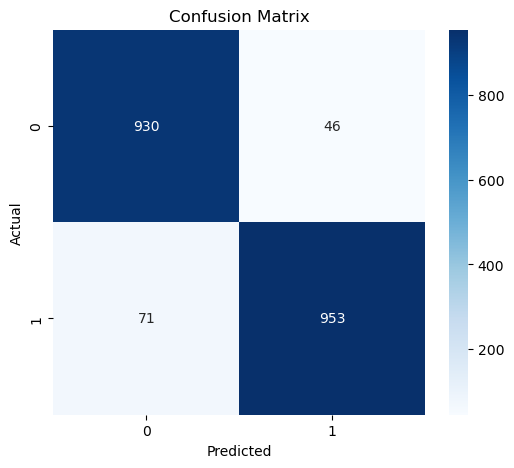

In [42]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       976
           1       0.95      0.93      0.94      1024

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
15,Current_Cash_Balance,0.220939
16,Transactions_Today,0.183924
12,Previous_Day_Withdrawals,0.149238
4,Location_Type,0.090397
22,Nearby_Businesses,0.052213
8,Salary_Week,0.043912
14,Cash_Loaded,0.043828
13,Average_Withdrawal_Amount,0.040755
6,Nearby_Market,0.027677
21,Population_Density,0.018627


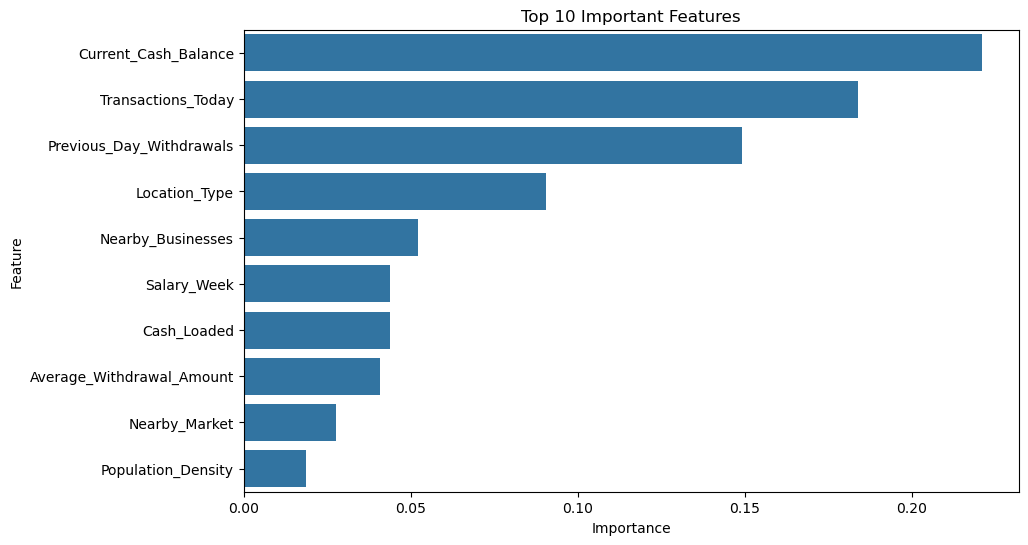

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [47]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Accuracy:
0.953375


In [48]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, best_predictions))

Test Accuracy: 0.9415


In [49]:
import joblib

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [50]:
loaded_model = joblib.load("best_model.pkl")

In [51]:
loaded_model.predict(X_test.iloc[:5])

array([0, 1, 0, 0, 0])